### RAG with Langgraph

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

In [ ]:
## Load Documents
loader = PyPDFLoader("../data/medical_report.pdf")
docs = loader.load()

## split into chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = splitter.split_documents(docs)

## embeddings & vector db
embed = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")
vector_store = InMemoryVectorStore.from_documents(
    documents=docs,
    embedding=embed
)


In [9]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [28]:
class RagState(BaseModel):
    question: str = Field(description="User Question")
    documents: list = []
    context: str = Field(description="Context data for user question", default="")
    answer: str = Field(description="Final Answer", default="")

In [29]:
# question -> retrieve -> context -> generate -> end
def retrieve_node(state:RagState) -> RagState:
    docs = vector_store.similarity_search(query=state.question)
    state.documents = docs
    return state

def create_context_node(state:RagState) -> RagState:
    context = ""
    for doc in state.documents:
        context += doc.page_content + "\n\n"
    state.context = context
    return state

def generate_node(state:RagState) -> RagState:
    prompt = f"""
        You're an assistant & provide the answer of user's question based on provided context & if you don't find the relevant answer then, just say I don't know.
        Context is: {state.context}
        Questino is: {state.question}
    """

    res = llm.invoke(prompt)
    state.answer = res.content
    return state
    



In [30]:
graph = StateGraph(RagState)
graph.add_node("retrieve_node", retrieve_node)
graph.add_node("create_context_node", create_context_node)
graph.add_node("generate_node", generate_node)

graph.add_edge(START, 'retrieve_node')
graph.add_edge('retrieve_node', 'create_context_node')
graph.add_edge('create_context_node', 'generate_node')
graph.add_edge('generate_node', END)

graph = graph.compile()

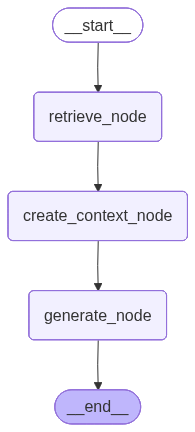

In [26]:
graph

In [36]:
result = graph.invoke({"question":"what is the RBC count & is it in range?"})

In [37]:
print(result["answer"])

The RBC count is 4.47 mill/mm^3, and according to the provided reference range (3.80 - 4.80 mill/mm^3), it is slightly above the range, but very close to the upper limit.
